<a href="https://colab.research.google.com/github/abhishek-marathe04/makemore/blob/main/building_makemore_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [223]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## We will be following this paper https://jmlr.org/papers/volume3/tmp/bengio03a.pdf

In [224]:
import requests

url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    words = response.text.replace(".", "").lower().splitlines()
    print(f"Downloaded {len(words)} names.")
    # print(words[:100])  # Show first 100 characters
else:
    print("Failed to download the file.")

Downloaded 55689 names.


In [225]:
words[:10]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh']

In [226]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [227]:
import torch

block_size = 3
X = []
Y = []
for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)

    # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
    context = context[1:] + [ix]


X = torch.tensor(X)
Y = torch.tensor(Y)

In [228]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [229]:
C = torch.randn(27,2)

In [230]:
C[5]

tensor([-0.7124,  0.6959])

In [231]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.7124,  0.6959])

In [232]:
C[X]

tensor([[[ 1.8434, -0.2853],
         [ 1.8434, -0.2853],
         [ 1.8434, -0.2853]],

        [[ 1.8434, -0.2853],
         [ 1.8434, -0.2853],
         [-0.9607, -0.2296]],

        [[ 1.8434, -0.2853],
         [-0.9607, -0.2296],
         [-0.9607, -0.2296]],

        ...,

        [[-0.4632, -1.9581],
         [ 0.7950,  0.2636],
         [-0.9607, -0.2296]],

        [[ 0.7950,  0.2636],
         [-0.9607, -0.2296],
         [ 1.6846, -1.6274]],

        [[-0.9607, -0.2296],
         [ 1.6846, -1.6274],
         [-0.9607, -0.2296]]])

In [233]:
C[X].shape

torch.Size([505438, 3, 2])

In [234]:
X[13,2]

tensor(1)

In [235]:
C[X[13,2]]

tensor([-0.9607, -0.2296])

In [236]:
C[1]

tensor([-0.9607, -0.2296])

In [237]:
emb = C[X]
emb.shape

torch.Size([505438, 3, 2])

In [238]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)

In [239]:
# emb @ w1
# RuntimeError: mat1 and mat2 shapes cannot be multiplied (111x2 and 6x100)

In [240]:
(emb.view(-1,6) @ w1) + b1

tensor([[-1.7871, -3.4831, -3.7377,  ...,  1.4648,  4.7860, -4.0971],
        [-5.2003,  1.2944,  0.4158,  ..., -1.8839,  0.4418, -2.5085],
        [-0.4201,  2.6044,  2.1404,  ..., -0.4220, -2.4992,  2.1289],
        ...,
        [-4.2220, -1.1420,  4.1312,  ..., -5.3086,  2.7690,  0.3978],
        [ 1.7976, -0.5368, -0.1770,  ...,  3.1589,  4.9631,  0.7990],
        [-9.6014,  1.2866,  3.0178,  ..., -4.4354,  4.5970, -0.2424]])

In [241]:
h = torch.tanh((emb.view(X.shape[0],6) @ w1) + b1) # Hidden layer activation

In [242]:
h.shape

torch.Size([505438, 100])

In [243]:
# Lets create final layer
# Input is 100 from hidden layer, and output is 27 possible characters
w2 = torch.randn(100,27)
b2 = torch.randn(27)
logits = h @ w2 + b2

In [244]:
logits.shape

torch.Size([505438, 27])

In [245]:
# We will apply softmax
counts = logits.exp()

In [246]:
prob = counts / counts.sum(1, keepdim=True)

In [247]:
prob.shape

torch.Size([505438, 27])

In [248]:
prob[1].sum()

tensor(1.)

In [249]:
torch.arange(32), Y

(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 tensor([ 1,  1,  2,  ..., 11,  1,  0]))

In [250]:
prob[torch.arange(X.shape[0]), Y]

tensor([6.4180e-11, 2.4797e-16, 3.0979e-06,  ..., 1.1500e-05, 5.1666e-10,
        3.3899e-14])

In [251]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(17.4125)

In [252]:
F.cross_entropy(logits, Y)

tensor(17.4125)

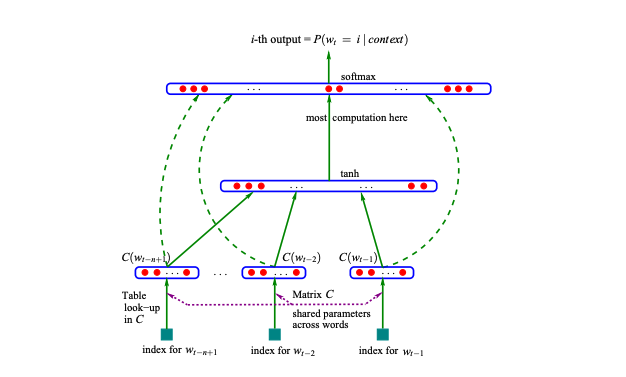

In [253]:
# --------- now made respectable -------

 We will be replicating above neural network where there will be 3 inputs, all will be get indexed to C which is our embedding array. We are storing all characters embedding in 2 dimention format so it will be (27,2) shape.
 Output of this layer would be 6 (2 from each neuron)

 It will then be an input to hidden layer. Our hidden layer will be formed by

> emb * W1 + b1




In [254]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [255]:
hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 2, generator=g, requires_grad=True)
W1 = torch.randn(6, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

3481

In [256]:
# emb = C[X] # (37,3, 2)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
# logits = h @ W2 + b2 # 37,27
# # counts = logits.exp()
# # prob = counts / counts.sum(1, keepdim=True)
# # loss = -prob[torch.arange(37), Y].log().mean()
# loss = F.cross_entropy(logits, Y)
# loss

We should always use cross entrophy from pytorch instead of our own implemention

Below are few reasons

* Model outputs logits (raw, unnormalized scores), not probabilities.
* Manual softmax can break for large logits, e.g. [100, 0, -100] → exp(100) overflows → inf / nan.

* Computing softmax and log manually can cause numerical instability (overflow → inf / nan).

* F.cross_entropy fuses log_softmax + negative log-likelihood using a numerically stable formulation.

* It is faster, more memory-efficient, and produces cleaner gradients.

* Rule: if your model outputs logits, pass them directly to F.cross_entropy — never apply softmax yourself.

In [257]:
for p in parameters:
  p.requires_grad = True

In [258]:
# torch.randint(0,X.shape[0], (500,)) # We will form minibatch using this

In [259]:
# Lets identify good learning rate
lre = torch.linspace(-3, 0, 1000)

lrs = 10**lre
# for i in range(10):
#     print(lrs[i].item())
# lrs

In [260]:
lri = []
lossi = []
for i in range(1000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (50,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  loss = F.cross_entropy(logits, Y[ix])
  # loss
  # print(loss.item())
  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = lrs[i]
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad

  # Track loss and lr
  lossi.append(loss.item())
  lri.append(lre[i])


print(loss)

tensor(6.8916, grad_fn=<NllLossBackward0>)


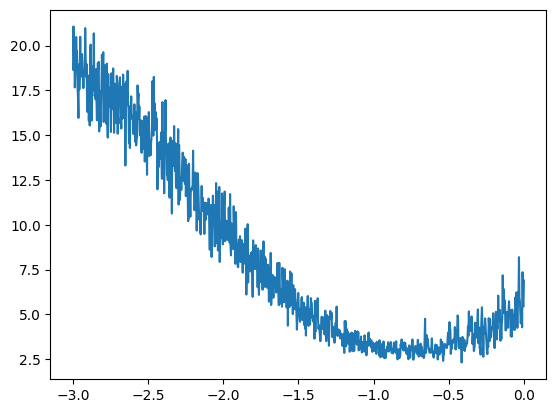

In [261]:
plt.plot(lri, lossi)

From Above Graph, it is clear that good learning exponent is around -1.0 or or 0.1

In [262]:
# Let again initilise everything, Now we know, we will use 0.1 learning rate

hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 2, generator=g, requires_grad=True)
W1 = torch.randn(6, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

3481

In [263]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(1.9932, grad_fn=<NllLossBackward0>)


In [264]:
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.1513, grad_fn=<NllLossBackward0>)

In [265]:
# Lets try to change some hyperparameters now to see if we can improve model. We have used 2 dimention embedding vector, lets try to use 10 dimention now

In [266]:
# Let again initilise everything, Now we know, we will use 10 dimentions in C

hidden_layers = 100
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn(27, 10, generator=g, requires_grad=True)
W1 = torch.randn(30, hidden_layers,generator=g, requires_grad=True)
b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
W2 = torch.randn(hidden_layers, 27, generator=g, requires_grad=True)
b2 = torch.randn(27, generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters) # Number of parameters in model

6097

In [267]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(1.9667, grad_fn=<NllLossBackward0>)


In [268]:
# Loss is good now
# Lets check for whole x
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.0344, grad_fn=<NllLossBackward0>)